# 2-Sample t-test <hr style="border:2.5px solid rgb(28, 75, 147)"></hr>

<b>Sidney Louise G. Monillo</b>
<br>Computer Engineer/Technician

In [112]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.power import TTestPower

In [113]:
# loading dataset
df = pd.read_csv(r"datasets/penguins.csv",
                 delimiter=",")

df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [115]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [116]:
# clean the data
df_clean = df[['sex','body_mass_g']].dropna()
df_clean

,sex,body_mass_g
0,MALE,3750.0
1,FEMALE,3800.0
2,FEMALE,3250.0
4,FEMALE,3450.0
5,MALE,3650.0
...,...,...
338,FEMALE,4925.0
340,FEMALE,4850.0
341,MALE,5750.0
342,FEMALE,5200.0


In [117]:
# create two groups
male_mass = df_clean[df_clean['sex'] == 'MALE']['body_mass_g']
female_mass = df_clean[df_clean['sex'] == 'FEMALE']['body_mass_g']

In [118]:
# summary of dataframe
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          333 non-null    object 
 1   body_mass_g  333 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.8+ KB


In [119]:
# summary of statistics
df_clean.describe()

,body_mass_g
count,333.000000
mean,4207.057057
std,805.215802
min,2700.000000
25%,3550.000000
50%,4050.000000
75%,4775.000000
max,6300.000000


# Bodymass of Male vs Female Penguins

In [120]:
"""
Summary of Statistics
-----------------------
"""
print("Male group:")
print(male_mass.describe())
print("\nFemale group:")
print(female_mass.describe())

Male group:
count     168.000000
mean     4545.684524
std       787.628884
min      3250.000000
25%      3900.000000
50%      4300.000000
75%      5312.500000
max      6300.000000
Name: body_mass_g, dtype: float64

Female group:
count     165.000000
mean     3862.272727
std       666.172050
min      2700.000000
25%      3350.000000
50%      3650.000000
75%      4550.000000
max      5200.000000
Name: body_mass_g, dtype: float64


C:\Users\sidne\AppData\Local\Temp\ipykernel_15688\1064259905.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male_mass, female_mass], labels=['Male', 'Female'])


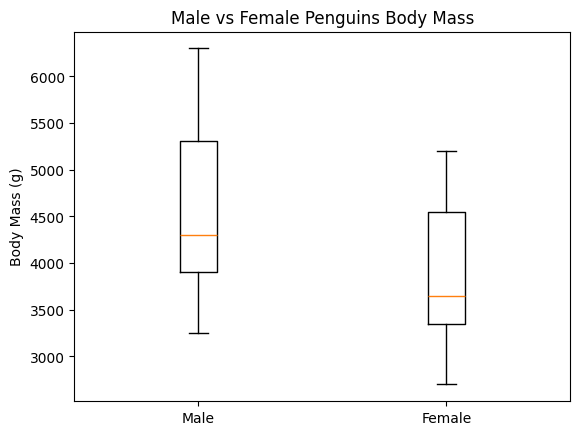

In [121]:
"""
Boxplot
----------------
"""
# check for outliers
plt.boxplot([male_mass, female_mass], labels=['Male', 'Female'])
plt.title("Male vs Female Penguins Body Mass")
plt.ylabel('Body Mass (g)')
plt.show()

In [122]:
"""
Normality Test
------------------
"""
alpha = 0.05
print("\nNormality Test (Shapiro-Wilk):")
for group, name in zip([male_mass, female_mass], ['Male','Female']):
    stat, p = stats.shapiro(group)
    print(f"{name}: W={stat:.4f}, p={p:.4f} -> ", end="")
    if p < alpha:
        print("Non-normal")
    else:
        print("Normal")


Normality Test (Shapiro-Wilk):
Male: W=0.9250, p=0.0000 -> Non-normal
Female: W=0.9193, p=0.0000 -> Non-normal


In [123]:
"""
F-Test 
--------------------------------
Ho: var_Male = var_Female
Ha: var_Male != var_Female
"""

var_male = male_mass.var(ddof=1)
var_female = female_mass.var(ddof=1)

if var_male > var_female:
    f_stat = var_male / var_female
    dfn, dfd = len(male_mass)-1, len(female_mass)-1
else:
    f_stat = var_female / var_male
    dfn, dfd = len(female_mass)-1, len(male_mass)-1

p_f = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))
print(f"\nF-test: F={f_stat:.4f}, p={p_f:.4f}")
if p_f < alpha:
    print("Reject H0 → Variances are unequal")
    equal_var_flag = False
else:
    print("Fail to reject H0 → Variances are equal")
    equal_var_flag = True

# Verdict
alpha = 0.05
if p_value < alpha:
    print("Reject H0 → variances are unequal")
else:
    print("Fail to reject H0 → variances are equal")


F-test: F=1.3979, p=0.0320
Reject H0 → Variances are unequal
Reject H0 → variances are unequal


In [124]:
"""
2 - Sample T-Test
----------------------------------------
Ho: Male <= Female
Ha: Male > Female
"""

t_stat, p_value = stats.ttest_ind(male_mass, female_mass, 
                                  alternative='greater',  # Male > Female
                                  equal_var=equal_var_flag)
print(f"\n2-Sample T-Test: t={t_stat:.4f}, p={p_value:.4f}")
if p_value < alpha:
    print("Reject H0 → Male penguins have significantly higher body mass than Female penguins.")
else:
    print("Fail to reject H0 → No significant difference in body mass between sexes.")


2-Sample T-Test: t=8.5545, p=0.0000
Reject H0 → Male penguins have significantly higher body mass than Female penguins.


In [125]:
"""
Power of the Test
------------------
Ho: μMale <= μFemale
Ha: μMale > μFemale
"""

# Means and standard deviations
male_mean = male_mass.mean()
female_mean = female_mass.mean()
n_male = len(male_mass)
n_female = len(female_mass)
s_male = male_mass.std(ddof=1)
s_female = female_mass.std(ddof=1)

# Pooled standard deviation
pooled_std = np.sqrt(((n_male-1)*s_male**2 + (n_female-1)*s_female**2) / (n_male + n_female - 2))

# Check for zero SD
if pooled_std == 0:
    cohens_d = 0
    power = 0
    print("Cohen's d: 0 (pooled SD = 0, identical data)")
    print("Power of the test: 0%")
else:
    # Cohen's d
    cohens_d = (male_mean - female_mean) / pooled_std
    print(f"Cohen's d: {cohens_d:.4f}")
    
    # For TTestPower, use nobs = size of one group (smaller group is safest)
    nobs = min(n_male, n_female)
    
    # Power of the test
    power = TTestPower().power(
        effect_size=abs(cohens_d),   # always positive
        nobs=nobs,
        alpha=0.05,
        alternative='larger'         # Male > Female
    )
    print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.9362
Power of the test: 100.00%
